# 06 - Visualize Technical Evaluation Results

This notebook builds summary plots from batch metrics.

Outputs are written to:
- `results/plots/summary/`
- `results/plots/summary/heatmaps/`


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except Exception:
    sns = None

plt.rcParams['figure.dpi'] = 130


In [2]:
ROOT = Path('/home/augusta/storage3/augusta/insituCNV/InSituCNV/Evaluate_technical_constrains')
RUNS_PATH = ROOT / 'manifests' / 'runs.csv'
METRICS_PATH = ROOT / 'results' / 'metrics' / 'metrics_master.csv'

PLOT_DIR = ROOT / 'results' / 'plots' / 'summary'
HEATMAP_DIR = PLOT_DIR / 'heatmaps'
PLOT_DIR.mkdir(parents=True, exist_ok=True)
HEATMAP_DIR.mkdir(parents=True, exist_ok=True)

assert RUNS_PATH.exists(), f'Missing runs manifest: {RUNS_PATH}'
assert METRICS_PATH.exists(), f'Missing metrics file: {METRICS_PATH}'

runs = pd.read_csv(RUNS_PATH)
metrics = pd.read_csv(METRICS_PATH)

print(f'runs rows: {len(runs)}')
print(f'metrics rows: {len(metrics)}')
print(f'unique metrics run_id: {metrics["run_id"].astype(str).nunique()}')


runs rows: 630
metrics rows: 609
unique metrics run_id: 609


## Standardize Ordering And Merge Status

We standardize panel/count ordering, then merge run status into metrics so all plots can show missing/failed runs explicitly.


In [3]:
count_order = [100, 70, 50, 20, 10, 5, 3, 2, 1]
gene_order = ['all', '20000', '15000', '10000', '5000', '1000', '500']

runs['run_id'] = runs['run_id'].astype(str)
metrics['run_id'] = metrics['run_id'].astype(str)

runs['count_fraction'] = pd.to_numeric(runs['count_fraction'], errors='coerce')
runs['gene_panel'] = runs['gene_panel'].astype(str)
metrics['count_fraction'] = pd.to_numeric(metrics['count_fraction'], errors='coerce')
metrics['gene_panel'] = metrics['gene_panel'].astype(str)

runs['count_fraction'] = pd.Categorical(runs['count_fraction'], categories=count_order, ordered=True)
runs['gene_panel'] = pd.Categorical(runs['gene_panel'], categories=gene_order, ordered=True)
metrics['count_fraction'] = pd.Categorical(metrics['count_fraction'], categories=count_order, ordered=True)
metrics['gene_panel'] = pd.Categorical(metrics['gene_panel'], categories=gene_order, ordered=True)

status_cols = ['run_id', 'template_id', 'count_fraction', 'gene_panel']
if 'status' in runs.columns:
    status_cols.append('status')
else:
    runs['status'] = 'unknown'
    status_cols.append('status')

merged = runs[status_cols].merge(
    metrics,
    on=['run_id', 'template_id', 'count_fraction', 'gene_panel'],
    how='left',
    suffixes=('_run', '')
)

merged['has_metrics'] = merged['ari'].notna()
print(merged[['status', 'has_metrics']].value_counts(dropna=False).to_string())


status    has_metrics
inferred  True           609
failed    False           21


## 1) Run Completeness Matrix

Shows, for each technical condition, how many runs are inferred and how many have computed metrics.


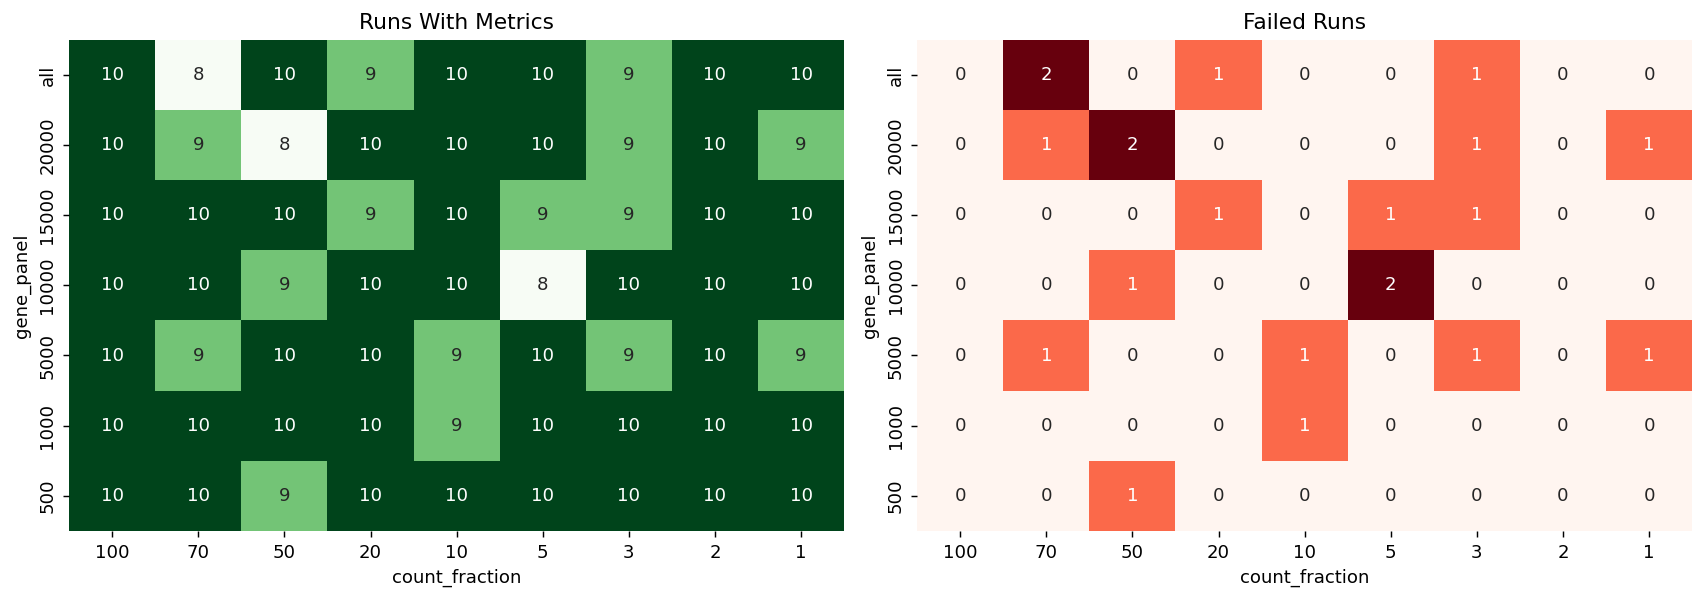

In [4]:
summary = (
    merged
    .groupby(['count_fraction', 'gene_panel'], observed=False)
    .agg(
        n_runs=('run_id', 'count'),
        n_inferred=('status', lambda x: int((x.astype(str).str.lower() == 'inferred').sum())),
        n_failed=('status', lambda x: int((x.astype(str).str.lower() == 'failed').sum())),
        n_with_metrics=('has_metrics', lambda x: int(x.sum())),
    )
    .reset_index()
)

pivot_metrics = summary.pivot(index='gene_panel', columns='count_fraction', values='n_with_metrics')
pivot_failed = summary.pivot(index='gene_panel', columns='count_fraction', values='n_failed')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

if sns is not None:
    sns.heatmap(pivot_metrics, annot=True, fmt='.0f', cmap='Greens', ax=axes[0], cbar=False)
    sns.heatmap(pivot_failed, annot=True, fmt='.0f', cmap='Reds', ax=axes[1], cbar=False)
else:
    im0 = axes[0].imshow(pivot_metrics.fillna(0).values, aspect='auto', cmap='Greens')
    im1 = axes[1].imshow(pivot_failed.fillna(0).values, aspect='auto', cmap='Reds')
    axes[0].set_yticks(range(len(pivot_metrics.index))); axes[0].set_yticklabels(pivot_metrics.index)
    axes[1].set_yticks(range(len(pivot_failed.index))); axes[1].set_yticklabels(pivot_failed.index)
    axes[0].set_xticks(range(len(pivot_metrics.columns))); axes[0].set_xticklabels(pivot_metrics.columns)
    axes[1].set_xticks(range(len(pivot_failed.columns))); axes[1].set_xticklabels(pivot_failed.columns)

axes[0].set_title('Runs With Metrics')
axes[1].set_title('Failed Runs')
for ax in axes:
    ax.set_xlabel('count_fraction')
    ax.set_ylabel('gene_panel')

fig.savefig(PLOT_DIR / 'completeness_heatmaps.png', dpi=220)
plt.show()


## 2) Performance Trends Across Count Fraction

Each panel tracks one metric vs count fraction.
Lines are averaged across templates, one line per gene panel.


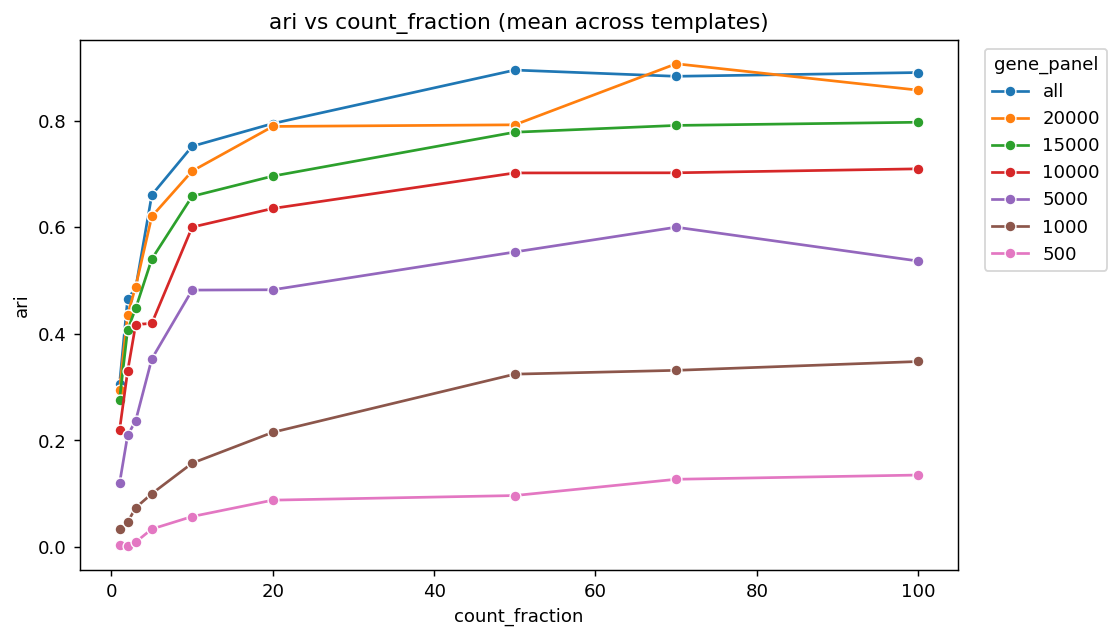

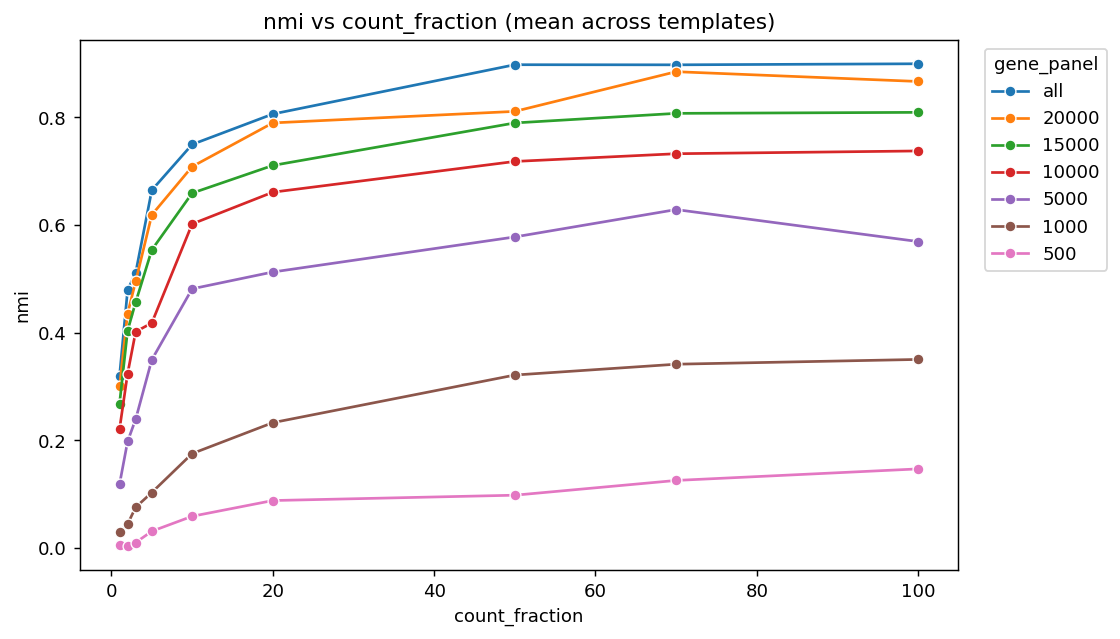

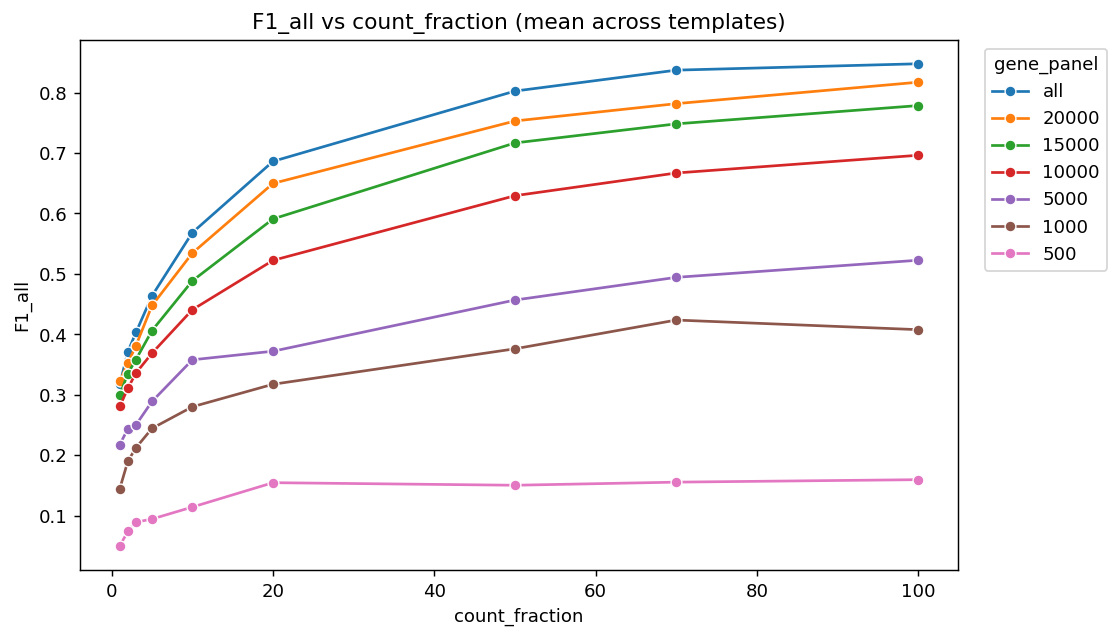

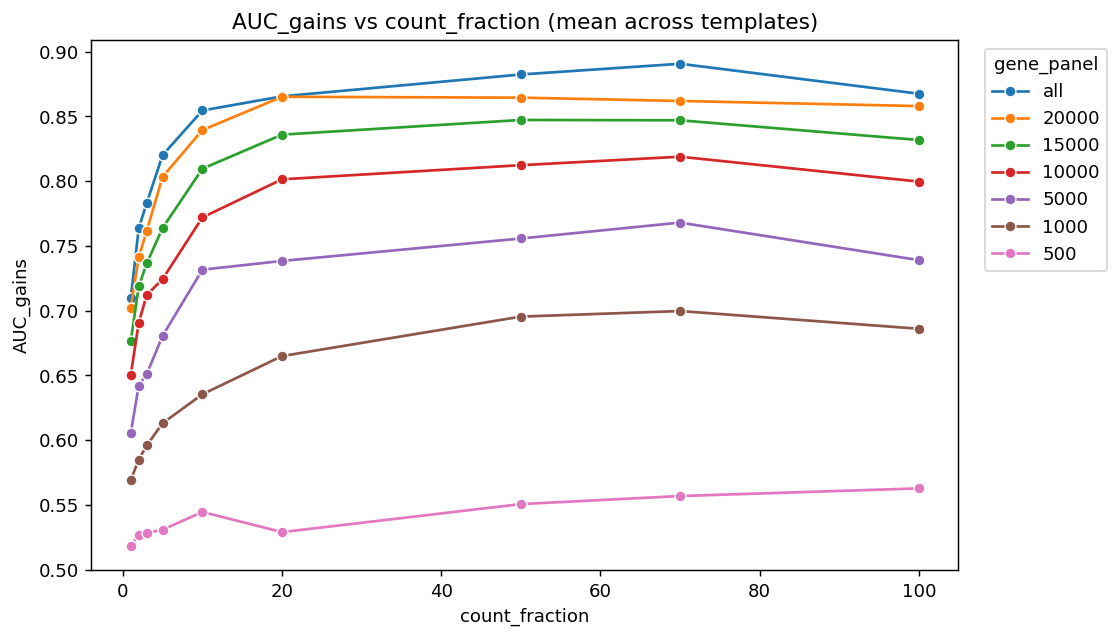

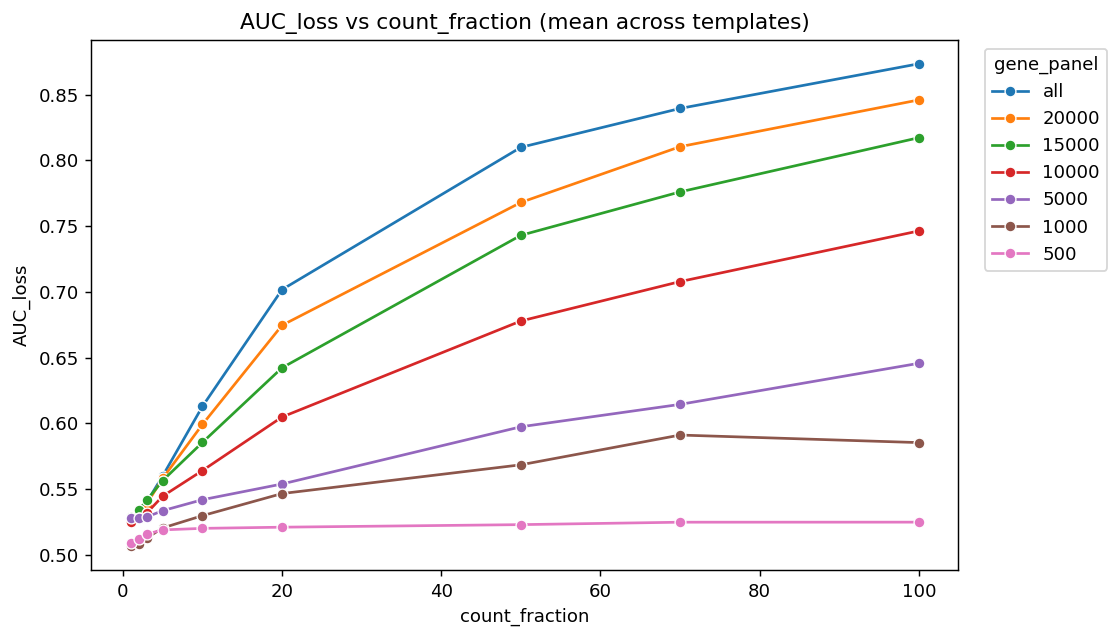

In [5]:
plot_metrics = ['ari', 'nmi', 'F1_all', 'AUC_gains', 'AUC_loss']

df = merged[merged['has_metrics']].copy()
for m in plot_metrics:
    df[m] = pd.to_numeric(df[m], errors='coerce')

for metric in plot_metrics:
    fig, ax = plt.subplots(1, 1, figsize=(8.5, 4.8), constrained_layout=True)
    if sns is not None:
        sns.lineplot(
            data=df,
            x='count_fraction',
            y=metric,
            hue='gene_panel',
            marker='o',
            estimator='mean',
            errorbar=None,
            ax=ax,
        )
    else:
        grp = (
            df.groupby(['gene_panel', 'count_fraction'], observed=False)[metric]
            .mean()
            .reset_index()
        )
        for gp, sub in grp.groupby('gene_panel', observed=False):
            ax.plot(sub['count_fraction'].astype(str), sub[metric], marker='o', label=str(gp))

    ax.set_title(f'{metric} vs count_fraction (mean across templates)')
    ax.set_xlabel('count_fraction')
    ax.set_ylabel(metric)
    ax.legend(title='gene_panel', bbox_to_anchor=(1.02, 1), loc='upper left')
    fig.savefig(PLOT_DIR / f'trend_{metric}.png', dpi=220)
    plt.show()


## 2b) Performance Trends Across Mean Counts Per Cell

Same metrics as above, but x-axis is `mean_countsxcell` instead of `count_fraction`.
Curves are still averaged across templates and split by gene panel.


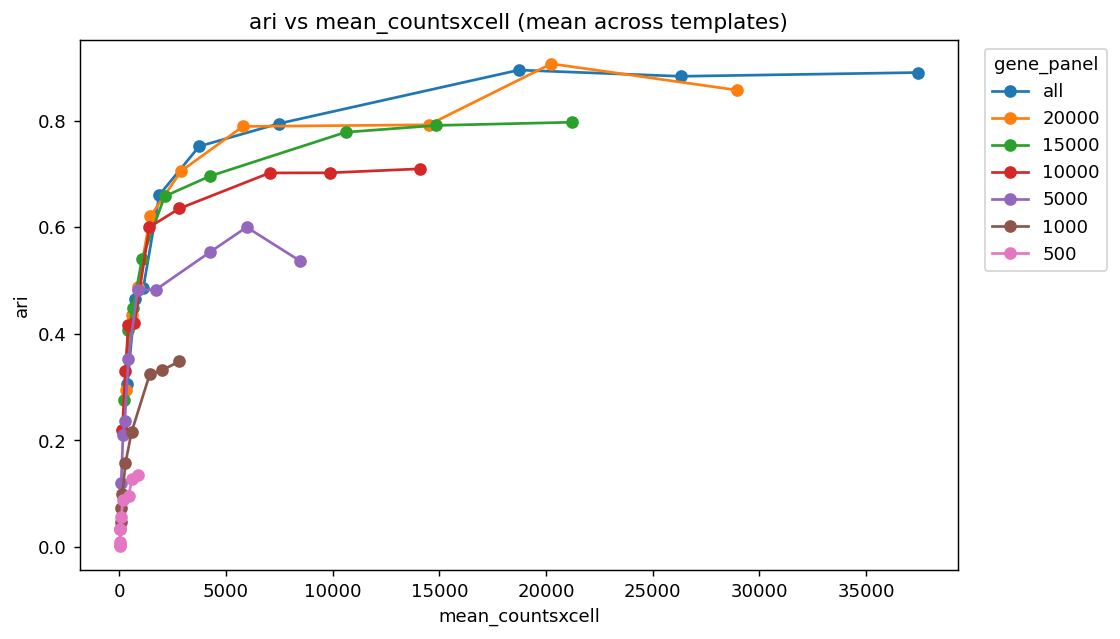

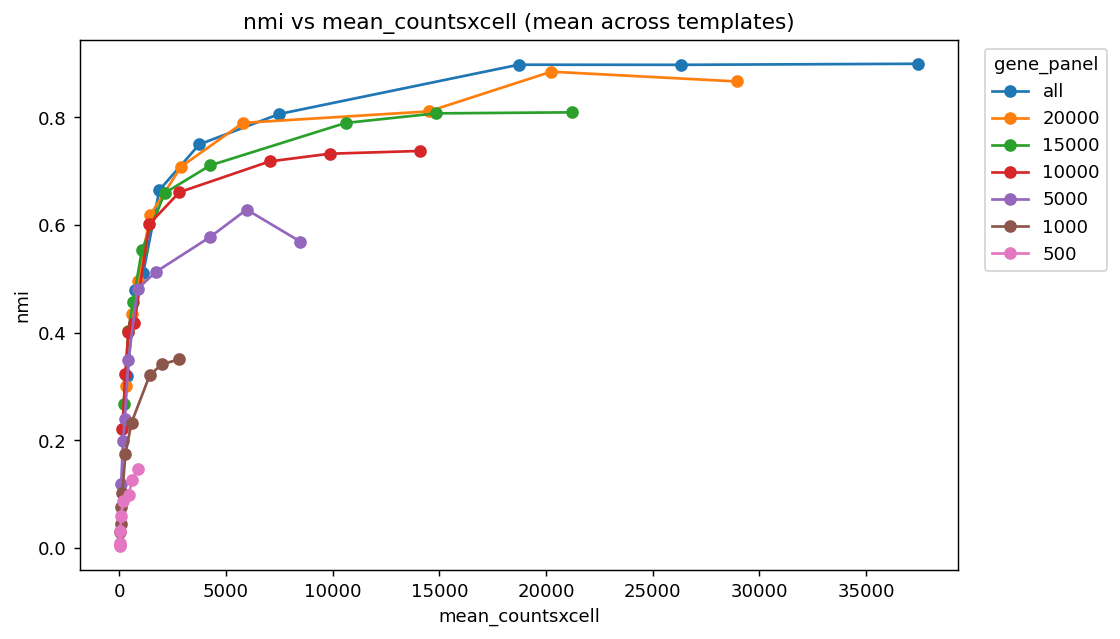

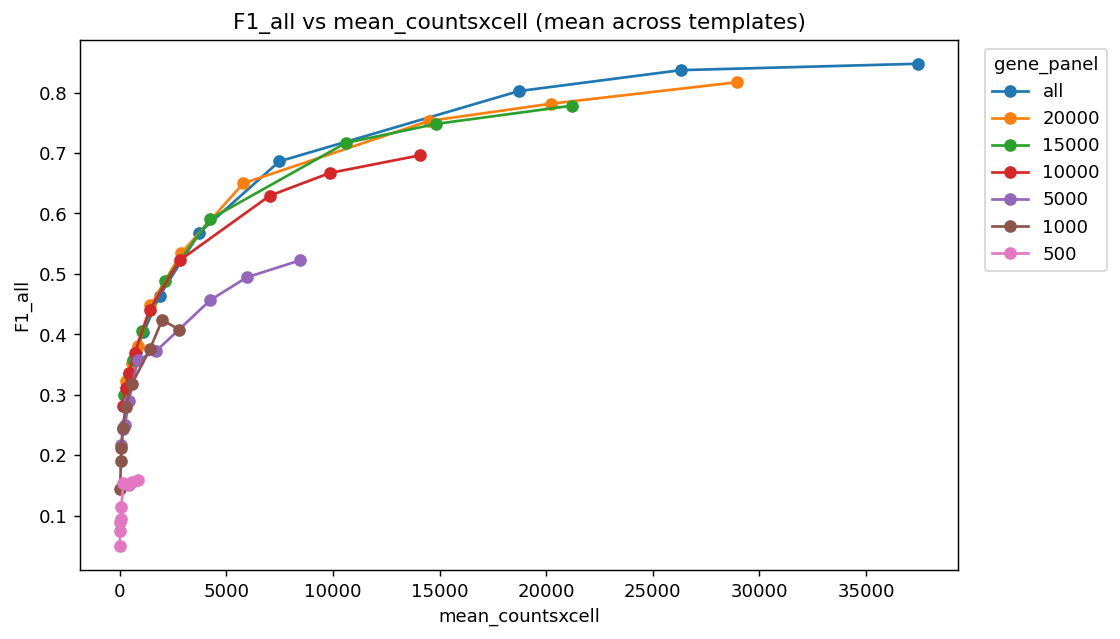

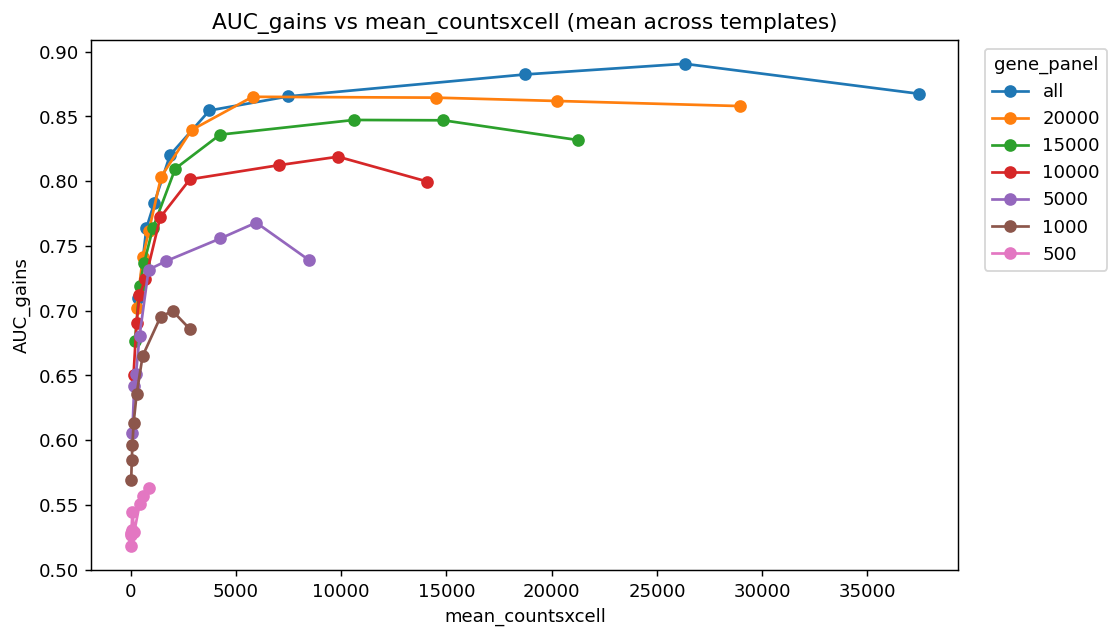

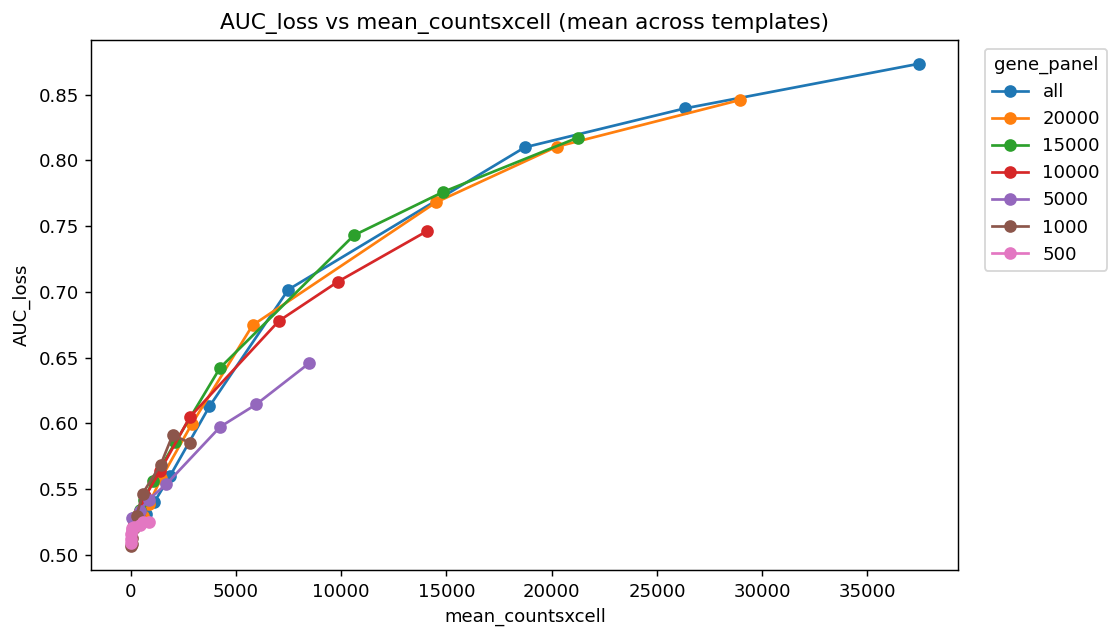

In [6]:
plot_metrics_counts = ['ari', 'nmi', 'F1_all', 'AUC_gains', 'AUC_loss']

df_counts = merged[merged['has_metrics']].copy()
for m in plot_metrics_counts + ['mean_countsxcell']:
    df_counts[m] = pd.to_numeric(df_counts[m], errors='coerce')

# Keep template-level rows; summarize distribution across templates per condition
agg = (
    df_counts.groupby(['template_id', 'gene_panel', 'count_fraction'], observed=False)
    .agg({
        'mean_countsxcell': 'mean',
        'ari': 'mean',
        'nmi': 'mean',
        'F1_all': 'mean',
        'AUC_gains': 'mean',
        'AUC_loss': 'mean',
    })
    .reset_index()
)

for metric in plot_metrics_counts:
    fig, ax = plt.subplots(1, 1, figsize=(9.0, 5.0), constrained_layout=True)

    for gp in gene_order:
        sub = agg[agg['gene_panel'].astype(str) == str(gp)].copy()
        if len(sub) == 0:
            continue

        stats = (
            sub.groupby('count_fraction', observed=False)
            .agg(
                x=('mean_countsxcell', 'mean'),
                y_mean=(metric, 'mean'),
                y_q25=(metric, lambda z: z.quantile(0.25)),
                y_q75=(metric, lambda z: z.quantile(0.75)),
                y_min=(metric, 'min'),
                y_max=(metric, 'max'),
            )
            .reset_index()
            .dropna(subset=['x', 'y_mean'])
            .sort_values('x')
        )

        if len(stats) == 0:
            continue

        # Mean trend
        ax.plot(
            stats['x'],
            stats['y_mean'],
            marker='o',
            linewidth=1.6,
            label=str(gp),
        )

        # 25-75% band
        ax.fill_between(
            stats['x'],
            stats['y_q25'],
            stats['y_q75'],
            alpha=0.18,
        )

        # Min-max range as vertical whiskers
        yerr_low = stats['y_mean'] - stats['y_min']
        yerr_high = stats['y_max'] - stats['y_mean']
        ax.errorbar(
            stats['x'],
            stats['y_mean'],
            yerr=[yerr_low, yerr_high],
            fmt='none',
            elinewidth=0.9,
            alpha=0.35,
            capsize=2,
        )

    ax.set_xscale('log')
    ax.set_xlabel('mean_countsxcell (log scale)')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs mean_countsxcell
(mean line, IQR band, min-max whiskers across templates)')
    ax.legend(title='gene_panel', bbox_to_anchor=(1.02, 1), loc='upper left')

    fig.savefig(PLOT_DIR / f'trend_countsxcell_{metric}.png', dpi=220)
    plt.show()



## 3) Template Heatmaps

For each template, generate two heatmaps:
- `F1_all`
- `ari`


In [7]:
def save_template_heatmap(sub_df, value_col, out_path, title):
    p = sub_df.pivot(index='gene_panel', columns='count_fraction', values=value_col)
    fig, ax = plt.subplots(1, 1, figsize=(6.2, 4.0), constrained_layout=True)
    if sns is not None:
        sns.heatmap(p, cmap='viridis', annot=False, ax=ax)
    else:
        im = ax.imshow(p.values, aspect='auto', cmap='viridis')
        ax.set_yticks(range(len(p.index))); ax.set_yticklabels(p.index)
        ax.set_xticks(range(len(p.columns))); ax.set_xticklabels(p.columns)
        fig.colorbar(im, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('count_fraction')
    ax.set_ylabel('gene_panel')
    fig.savefig(out_path, dpi=220)
    plt.close(fig)

templates = sorted(df['template_id'].dropna().astype(str).unique())
for tid in templates:
    sub = df[df['template_id'].astype(str) == tid]
    save_template_heatmap(
        sub,
        'F1_all',
        HEATMAP_DIR / f'heatmap_F1_all_{tid}.png',
        f'{tid} - F1_all'
    )
    save_template_heatmap(
        sub,
        'ari',
        HEATMAP_DIR / f'heatmap_ari_{tid}.png',
        f'{tid} - ARI'
    )

print(f'Saved heatmaps for {len(templates)} templates to: {HEATMAP_DIR}')


Saved heatmaps for 10 templates to: /home/augusta/storage3/augusta/insituCNV/InSituCNV/Evaluate_technical_constrains/results/plots/summary/heatmaps


## 4) Template-Level Summary Bars

Average each metric across all available technical conditions per template.


,template_id,ari,nmi,F1_all,AUC_gains,AUC_loss
0,T01,0.537972,0.525541,0.423647,0.769925,0.601215
1,T02,0.377866,0.407627,0.563459,0.780003,0.588802
2,T03,0.271783,0.283405,0.294191,0.660928,0.573364
3,T04,0.109047,0.129121,0.216353,0.571344,0.567409
4,T05,0.654536,0.652845,0.555966,0.788611,0.600480
5,T06,0.356314,0.385813,0.350423,0.683589,0.603620
6,T07,0.130548,0.149397,0.302717,0.651374,0.574402
7,T08,0.678489,0.669893,0.494189,0.782757,0.623399
8,T09,0.561565,0.550464,0.467010,0.772084,0.600850
9,T10,0.716219,0.708920,0.457166,0.746057,0.627187


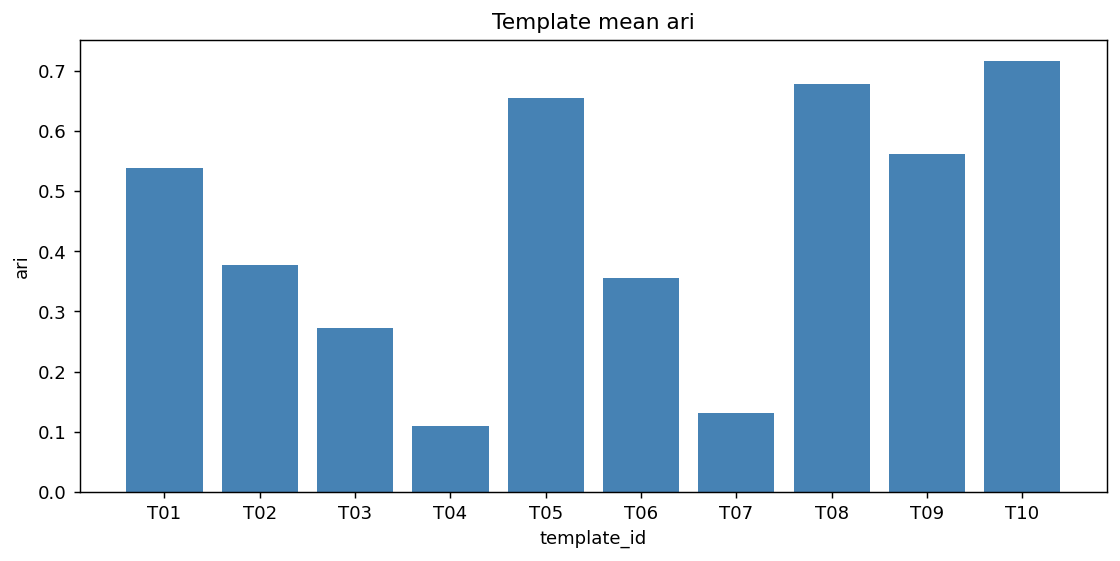

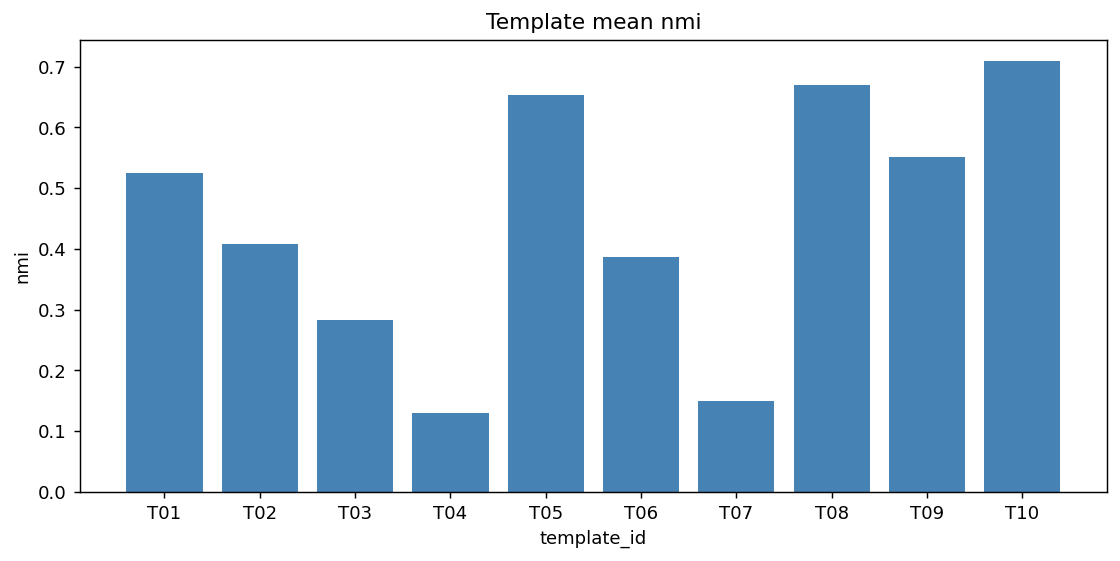

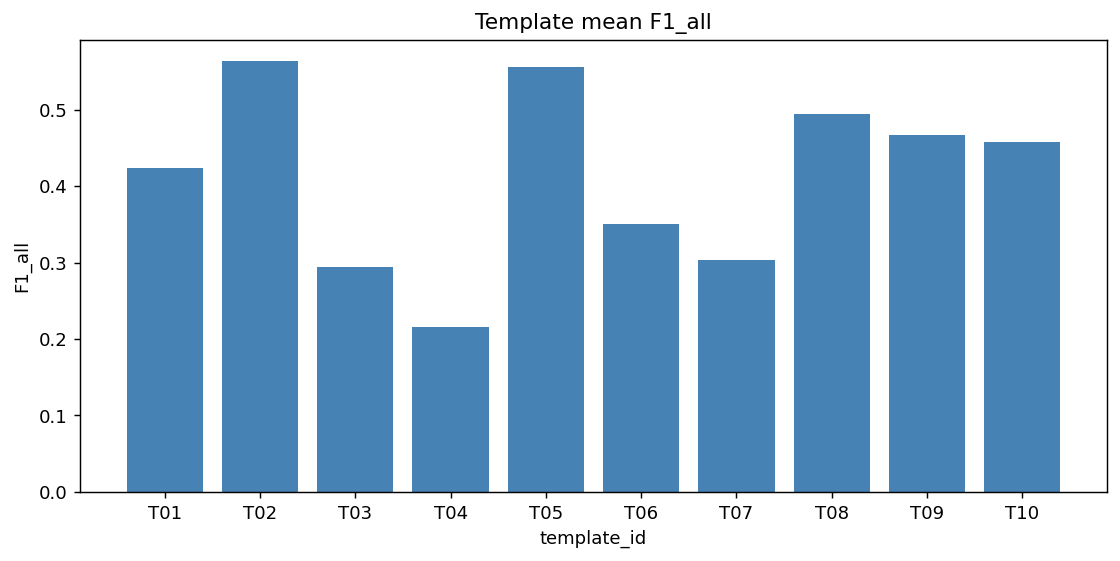

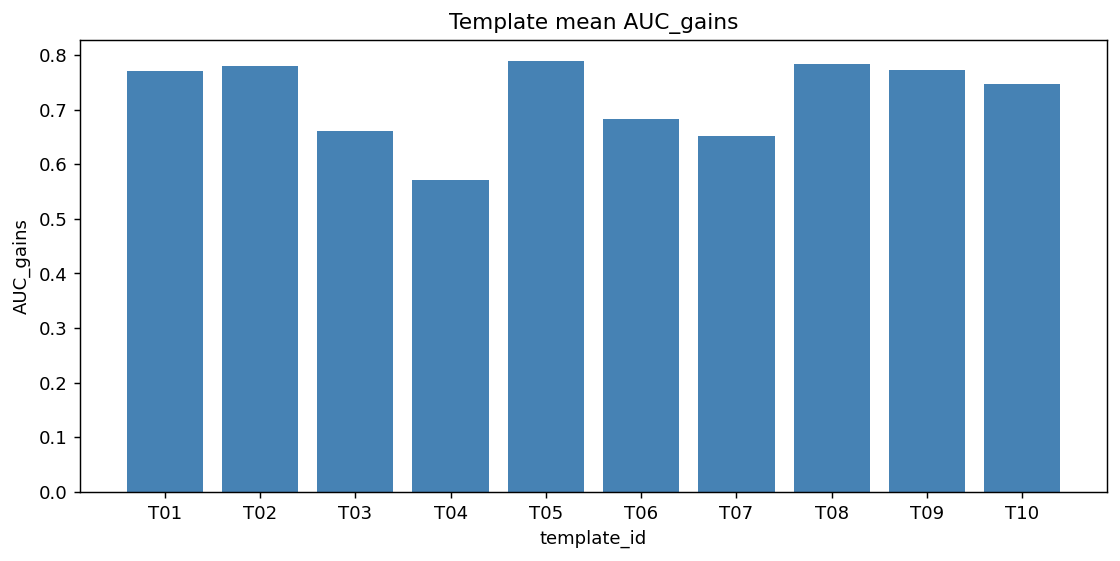

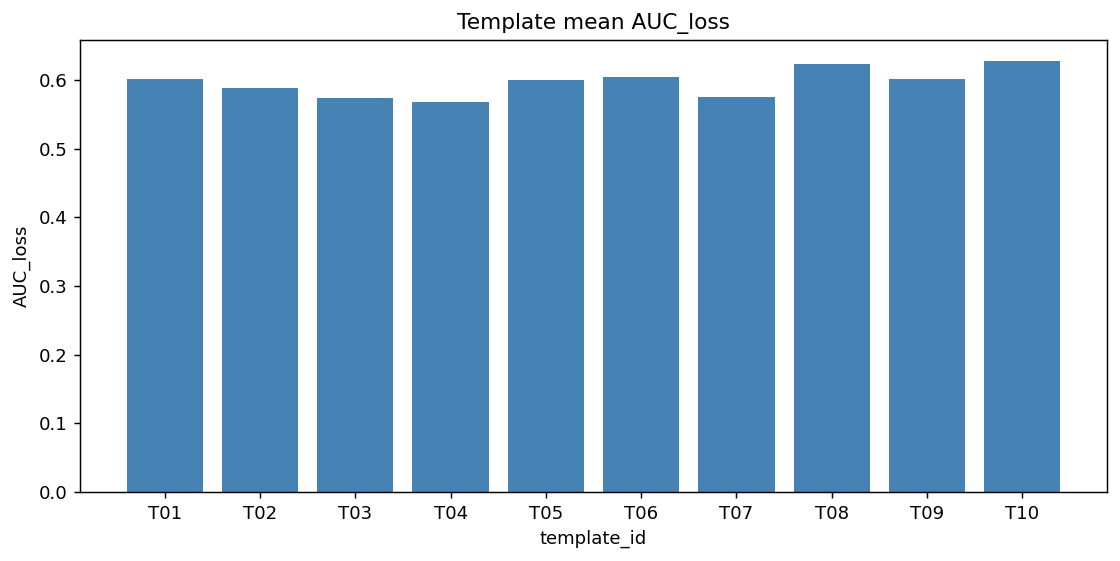

In [8]:
summary_metrics = ['ari', 'nmi', 'F1_all', 'AUC_gains', 'AUC_loss']
template_mean = (
    df.groupby('template_id', observed=False)[summary_metrics]
    .mean()
    .reset_index()
    .sort_values('template_id')
)

display(template_mean)

for metric in summary_metrics:
    fig, ax = plt.subplots(1, 1, figsize=(8.5, 4.2), constrained_layout=True)
    ax.bar(template_mean['template_id'].astype(str), template_mean[metric], color='steelblue')
    ax.set_title(f'Template mean {metric}')
    ax.set_xlabel('template_id')
    ax.set_ylabel(metric)
    fig.savefig(PLOT_DIR / f'template_mean_{metric}.png', dpi=220)
    plt.show()


## 5) Export Missing-Run Table

Useful for deciding whether to rerun inferCNV on failed conditions.


In [9]:
missing = merged[~merged['has_metrics']].copy()
missing = missing[['run_id', 'template_id', 'count_fraction', 'gene_panel', 'status']].sort_values(
    ['template_id', 'count_fraction', 'gene_panel']
)
missing_out = PLOT_DIR / 'runs_missing_metrics.csv'
missing.to_csv(missing_out, index=False)

print(f'Missing metrics rows: {len(missing)}')
print(f'Saved: {missing_out}')
display(missing.head(30))


Missing metrics rows: 21
Saved: /home/augusta/storage3/augusta/insituCNV/InSituCNV/Evaluate_technical_constrains/results/plots/summary/runs_missing_metrics.csv


,run_id,template_id,count_fraction,gene_panel,status
115,T02_C70_G20000,T02,70,20000,failed
222,T04_C10_G5000,T04,10,5000,failed
370,T06_C70_Gall,T06,70,all,failed
360,T06_C50_G20000,T06,50,20000,failed
352,T06_C20_G15000,T06,20,15000,failed
343,T06_C10_G1000,T06,10,1000,failed
433,T07_C70_Gall,T07,70,all,failed
432,T07_C70_G5000,T07,70,5000,failed
381,T07_C1_G20000,T07,1,20000,failed
383,T07_C1_G5000,T07,1,5000,failed
